# Building input files

In this notebook we will run some simple examples of how to use the classes in hanlertmodlib.py to build the input files for the synthesis and inversion modes of HanleRT-TIC

IMPORTANT: I do not use this library to build the inputs, so the debug was very limited. If you find any issue while using it yourself, please, notify me so I can fix it.

# 1. Inversion file

In this first example we will create the file with the data for an inversion. In this example we will load data from a fits file from GRIS.

Remember that hanlertmodhelper_inversion.py has a very long explanation of what functions to call for many more cases.

We only need to import the hanlertmodlib and numpy, because we will work with numpy.array objects.
In this case we import fits from astropy.io because our data is in fits form.
We import matplotlib for ilustrative purposes and hanlertio.py to showcase the resulting file.

In [1]:
import hanlertmodlib as hrtml
import numpy as np
from astropy.io import fits
import matplotlib.pyplot as plt
import hanlertio

We just read the data. To make it simple, we will normalize the Stokes parameters to the average continuum (even if we have very few pixels) and provide a very rough wavelength calibration.

Shape of the data:  (4, 4, 4, 1000)


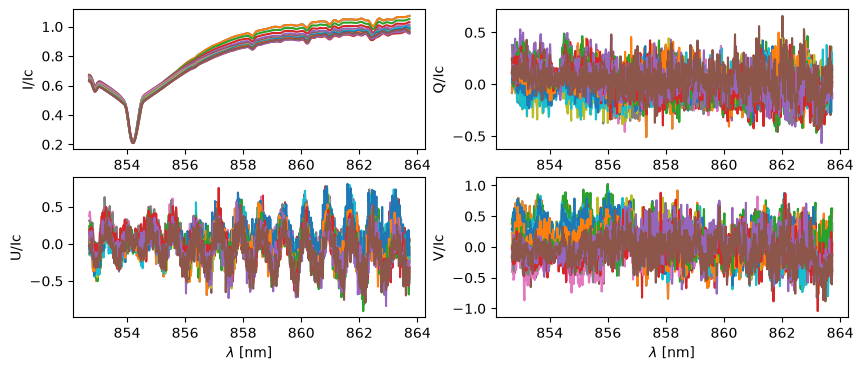

In [2]:
# Get data. We reshape because GRIS fits have Stokes and one spatial dimension mixed
data = fits.getdata('example_data/gris.fits').reshape((4,4,4,1000))
print('Shape of the data: ',data.shape)

# We build the wavelength with the usual dispersion scale
step = 0.01104 # nm
lamb = np.linspace(0.,data.shape[-1]*step,data.shape[-1],endpoint=False)
lamb = lamb - lamb[np.argmin(np.mean(data[0,:,:,:],axis=(0,1)))]
lamb += 854.209 #nm

# We get the average of the intensity at the last wavelength to normalize everything
Inorm = 1e0/np.mean(data[0,:,:,-1])

# We also need to provide errors, let's assume that we have a 1% of the continuum in intensity and 10^-3 in polarization
sigmas = np.array([1e-2,1e-3,1e-3,1e-3])

# We need to introduce the Stokes parameters in physical units. Here we assume that our 1.0 is the disk-center
# continuum as tabulated in Allen's book. We can get the corresponding intensity from the helper, which just
# interpolates in the mentioned tabulation. Note that get_radiation returns cgs and thus the division by 10^3
# NOTE: We need scipy to use this
allen = hrtml.allen_class()
Ic = allen.get_radiation(lamb[-1])*1e-3

# Plot profiles just to showcase
fig = plt.figure(figsize=(10,4))
for i,f,t in zip(range(4),[1e0,1e2,1e2,1e2],['I/Ic','Q/Ic','U/Ic','V/Ic']):
    ax = plt.subplot(221 + i)
    for ix in range(data.shape[0]):
        for iy in range(data.shape[1]):
            ax.plot(lamb,data[i,ix,iy,:]*f*Inorm)
            if i >= 2: ax.set_xlabel(r'$\lambda$ [nm]')
            ax.set_ylabel(t)
plt.show()

Now we just create an instance of the helper class and fill the data

In [3]:
# Initialize the instance of the helper with the output file name
helper = hrtml.invi_class('example_data/inversion_example.tic')

# We have wavelengths in air and we need them in vacuum, we can convert them (the function expects Angstroms)
lamb_vac = hrtml.airtovacuum(lamb*1e1)*1e-1

# NOTE: Sometimes, the transformation to vacuum is not perfect and an artificial shift remains.
# This can be problematic in inversions because it is not easy to retrieve an homogeneous velocity on top of a stratification.
# Therefore, instead of converting with airtovacuum, I build it relative to the line center.
# The air wavelength can be found in many places, e.g. NIST. The vacuum can also be found there, or easily calculated form the energies of the levels.
lamb_vac = lamb - 854.209 + 854.443791269635

# We load the vacuum wavelengths
check = helper.load_wavelength(lamb_vac)
if check:
    print('Wavelength loaded in the helper')
else:
    print('Could not load wavelength')

# We say that the LOS is disk-center for every pixel (so 0 heliocentric angle and azimuth)
check = helper.load_los(np.zeros((2)))
if check:
    print('LoS loaded in the helper')
else:
    print('Could not load LoS')

# We now load the Stokes parameters in SI units
# The ix, iy, and istk variables are indicating the dimension position
# of the x, y, and stokes dimensions in the array. These arguments
# are necessary for the helper to interpret the data being loaded
# correctly
check = helper.load_data(data*Ic*Inorm,ix=1,iy=2,istk=0)
if check:
    print('Data loaded in the helper')
else:
    print('Could not load data')

# We also build and load the sigma data array
data_sigma = data[:,:,:,-1]*Ic
for i in range(4): data_sigma[i,:,:] *= sigmas[i]
data_sigma = np.expand_dims(data_sigma, axis=-1)
data_sigma = np.broadcast_to(data_sigma,data.shape)
check = helper.load_sig(data_sigma,ix=1,iy=2,istk=0,polarization=True)
if check:
    print('Sigma loaded in the helper')
else:
    print('Could not load Sigma')

# And we create the file
check = helper.create_file()
if check:
    print('Your data file is ready at {0}'.format('example_data/inversion_example.tic'))
else:
    print('Could not create the file')
print('------------------------------------------')

Wavelength loaded in the helper
Provided a single LOS
LoS loaded in the helper
Provided a full data cube
Data loaded in the helper
Provided a full sigma cube
Sigma loaded in the helper
Your data file is ready at example_data/inversion_example.tic
------------------------------------------


The file would be ready for HanleRT-TIC

We can check that is was built correctly using the reader.

Inversion input file


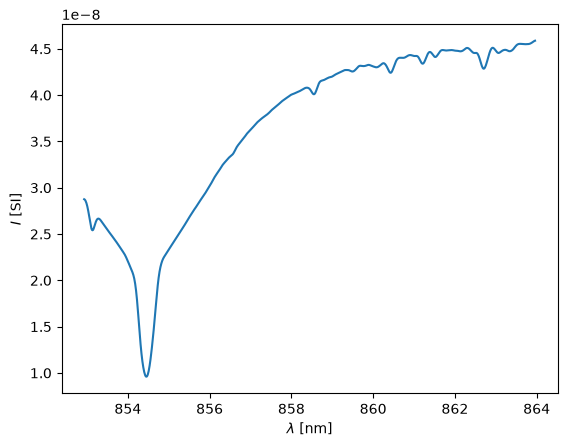

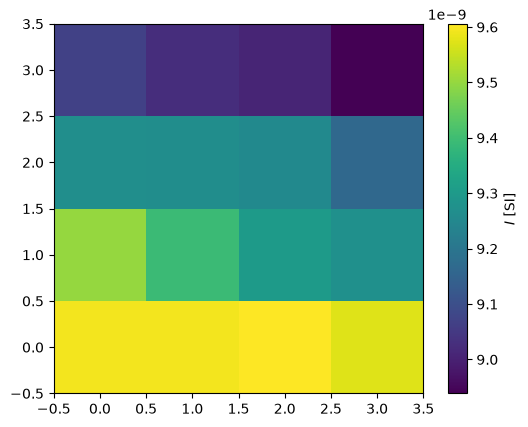

In [4]:
data = hanlertio.hanlertio_class('example_data/inversion_example.tic')
ax = plt.subplot()
ax.plot(data.get_lambda(),data.get_stokesi_column(0,0))
ax.set_xlabel(r'$\lambda$ [nm]')
ax.set_ylabel(r'$I$ [SI]')
plt.show()
ax = plt.subplot()
ref = ax.imshow(data.get_stokesi_plane(np.argmin(data.get_stokesi_column(0,0))),origin='lower')
cb = plt.colorbar(ref,ax=ax)
cb.set_label(r'$I$ [SI]')
plt.show()



# 2. Synthesis file (1D)

In this example we will create the atmospheric file with the data for a 1D synthesis.

In this example we will load data from a slice of the public Bifrost cube and take just one column. The original model is the snapshot 541 of the en024048_hion model hosted at https://sdc.uio.no/search/simulations. Information about this simulation can be found in the IRIS Technical Note 33.

The model resulting from this example is not suitable for calculations, as we have kept only a few essential variables and reduced their resolution significantly while keeping the original format.

Remember that hanlertmodhelper_synthesis1D.py has a very long explanation of what functions to call for other cases.
    

In [5]:
import hanlertmodlib as hrtml
import numpy as np
from astropy.io import fits
import matplotlib.pyplot as plt
import hanlertio

In [6]:
# Initialize the instance of the helper with the output file name
helper = hrtml.atmo1D_class('example_data/syn1D_example.atmos')

# We ask for the names of the variables
print('Variable list:')
helper.variable_list()
print('')

Variable list:
- h  : height [km]
- tau/ltau: optical depth (not/yes logarithmic)
- t  : temperature [K]
- pg : Gas pressure [dyn cm^-2]
- rho: Density [cm^-3]
- bx : Magnetic field X component [G]
- by : Magnetic field Y component [G]
- bz : Magnetic field Z component [G]
- vx : Velocity X component [km s^-1]
- vy : Velocity Y component [km s^-1]
- vz : Velocity Z component [km s^-1]
- vmi: Microturbulent velocity
- pe : Electron pressure [dyn cm^-2]
- rhoe: Electron density [cm^-3]
- ne : Electron number density [cm^-3]
- nht: Total hydrogen number density [cm^-3]
- nha: Atomic hydrogen number density [cm^-3]
- nhm: H- number density [cm^-3]
- nh0: Ground level hydrogen number density [cm^-3]
- nh1: First excited level hydrogen number density [cm^-3]
- nh2: Second excited level hydrogen number density [cm^-3]
- nh3: Third excited level hydrogen number density [cm^-3]
- nh4: Fourth excited level hydrogen number density [cm^-3]
- np : Proton number density [cm^-3]



In [7]:
# We can give a name and a comment that we will be able to read in the resulting ASCII file
helper.set_name('syn1D_example')
helper.set_comment('This model has been created in the notebook showcasing examples of hanlertmodlib as a tool to build inputs for HanleRT-TIC')

# We will take the columns (5,5)
ix = 5
iy = 5

# Get z axis (this is contained in every variable fits) and load it in km (original is in Mm)
check = helper.load_data(fits.getdata('example_data/BIF_lgtg.fits',1)*1e3,'h')
if check:
    print('Z axis loaded in the helper')
else:
    print('Could not load Z axis')

# We do the same with the temperature to load it in K (original is logarith of K)
# We also know that the order of the axes in the original data is Z-Y-X
check = helper.load_data(10.**fits.getdata('example_data/BIF_lgtg.fits')[:,iy,ix],'t')
if check:
    print('Temperature loaded in the helper')
else:
    print('Could not load temperature')

# Electron number density in cm^-3 (original in logarith of cm^-3)
check = helper.load_data(10.**fits.getdata('example_data/BIF_lgne.fits')[:,iy,ix],'ne')
if check:
    print('Electron number density loaded in the helper')
else:
    print('Could not load temperature')

# And vertical velocity in km s^-1 (original in m s^-1)
check = helper.load_data(fits.getdata('example_data/BIF_uz.fits')[:,iy,ix]*1e-3,'vz')
if check:
    print('Vertical velocity loaded in the helper')
else:
    print('Could not load vertical velocity')

# And with this we can create the file
check = helper.create_file()
if check:
    print('Your data file is ready at {0}'.format('example_data/syn1D_example.atmos'))
else:
    print('Could not create the file')
print('------------------------------------------')

Z axis loaded in the helper
Temperature loaded in the helper
Electron number density loaded in the helper
Vertical velocity loaded in the helper
Your data file is ready at example_data/syn1D_example.atmos
------------------------------------------


The file would be ready for HanleRT-TIC

We can check that is was built correctly using the reader

In [8]:
data = hanlertio.hanlertio_class('example_data/syn1D_example.atmos')

# We can ask for the content (remember that data.help() list the available methods for the loaded data)
print('List of variables and units:')
for line in data.get_vars_units(): print('  -'+line)

# And how to retrieve the variables
print('List of alias to request variables:')
for line in data.get_vars_alias(): print('  -'+line)


List of variables and units:
  -h [km]
  -T [K]
  -N$_{\rm e}$ [cm$^{-3}$]
  -v$_{\rm z} [km s$^{-1}$]
  -v$_{\rm mi} [km s$^{-1}$]
List of alias to request variables:
  -h -> h
  -T -> T
  -N$_{\rm e}$ -> ne
  -v$_{\rm z} -> vz
  -v$_{\rm mi} -> vmi


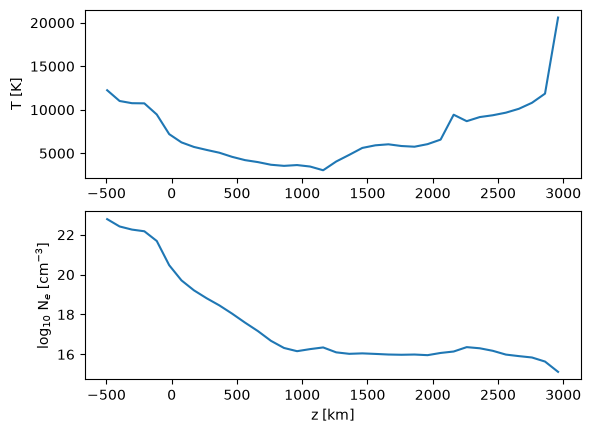

In [9]:
# We can also check that the stratifications look fine
column = data.get_column(var=['h','T','ne'])
ax = plt.subplot(211)
ax.plot(column['h'],column['T'])
ax.set_ylabel('T [K]')
ax = plt.subplot(212)
ax.plot(column['h'],np.log10(column['ne']))
ax.set_xlabel('z [km]')
ax.set_ylabel(r'log$_{10}$ N$_{e}$ [cm$^{-3}$]')
plt.show()

# 3. Synthesis file (1.5D)

In this example we will create the atmospheric file with the data for a 1.5D synthesis (3D model).

In this example we will load data from a slice of the public Bifrost cube and take just one column. The original model is the snapshot 541 of the en024048_hion model hosted at https://sdc.uio.no/search/simulations. Information about this simulation can be found in the IRIS Technical Note 33.

The model resulting from this example is not suitable for calculations, as we have kept only a few essential variables and reduced their resolution significantly while keeping the original format.

Remember that hanlertmodhelper_synthesis15D.py has a very long explanation of what functions to call for other cases.

In [10]:
import hanlertmodlib as hrtml
import numpy as np
from astropy.io import fits
import matplotlib.pyplot as plt
import hanlertio

In [11]:
# TODO DELETE THIS
import importlib
importlib.reload(hrtml)
importlib.reload(hanlertio)

# Initialize the instance of the helper with the output file name
helper = hrtml.atmo15D_class('example_data/syn15D_example.atmos')

# We ask for the names of the variables
print('Variable list:')
helper.variable_list()
print('')

Variable list:
- h  : height [km]
- tau/ltau: optical depth (not/yes logarithmic)
- t  : temperature [K]
- pg : Gas pressure [dyn cm^-2]
- rho: Density [cm^-3]
- bx : Magnetic field X component [G]
- by : Magnetic field Y component [G]
- bz : Magnetic field Z component [G]
- vx : Velocity X component [km s^-1]
- vy : Velocity Y component [km s^-1]
- vz : Velocity Z component [km s^-1]
- vmi: Microturbulent velocity
- pe : Electron pressure [dyn cm^-2]
- ne : Electron number density [cm^-3]
- nht: Total hydrogen number density [cm^-3]
- nha: Atomic hydrogen number density [cm^-3]
- nhm: H- number density [cm^-3]
- nh0: Ground level hydrogen number density [cm^-3]
- nh1: First excited level hydrogen number density [cm^-3]
- nh2: Second excited level hydrogen number density [cm^-3]
- nh3: Third excited level hydrogen number density [cm^-3]
- nh4: Fourth excited level hydrogen number density [cm^-3]
- np : Proton number density [cm^-3]



In [12]:
# We first get the shape of the data, because we need the horizontal extensions to feed the vertical axis
shape = fits.getdata('example_data/BIF_lgtg.fits').shape

# Get z axis (this is contained in every variable fits) and load it in km (original is in Mm)
# Because we only have one single dimension, we broadcast the column
# IMPORTANT: Note that because of how broadcast_to works, we have reversed the order of indexes, and the ix, iy, and iz arguments
#            are different than for the other variables below
check = helper.load_data(np.broadcast_to(fits.getdata('example_data/BIF_lgtg.fits',1)*1e3,shape[::-1]),'h',ix=0,iy=1,iz=2)
if check:
    print('Z axis loaded in the helper')
else:
    print('Could not load Z axis')

# We do the same with the temperature to load it in K (original is logarith of K)
# We also know that the order of the axes in the original data is Z-Y-X
check = helper.load_data(10.**fits.getdata('example_data/BIF_lgtg.fits'),'t',ix=2,iy=1,iz=0)
if check:
    print('Temperature loaded in the helper')
else:
    print('Could not load temperature')

# Electron number density in cm^-3 (original in logarith of cm^-3)
check = helper.load_data(10.**fits.getdata('example_data/BIF_lgne.fits'),'ne',ix=2,iy=1,iz=0)
if check:
    print('Electron number density loaded in the helper')
else:
    print('Could not load temperature')

# And vertical velocity in km s^-1 (original in m s^-1)
check = helper.load_data(fits.getdata('example_data/BIF_uz.fits')*1e-3,'vz',ix=2,iy=1,iz=0)
if check:
    print('Vertical velocity loaded in the helper')
else:
    print('Could not load vertical velocity')

# And with this we can create the file
check = helper.create_file()
if check:
    print('Your data file is ready at {0}'.format('example_data/syn15D_example.atmos'))
else:
    print('Could not create the file')
print('------------------------------------------')

Z axis loaded in the helper
Temperature loaded in the helper
Electron number density loaded in the helper
Vertical velocity loaded in the helper
Your data file is ready at example_data/syn15D_example.atmos
------------------------------------------


The file would be ready for HanleRT-TIC

We can check that is was built correctly using the reader

In [13]:
data = hanlertio.hanlertio_class('example_data/syn15D_example.atmos')

# We can ask for the content (remember that data.help() list the available methods for the loaded data)
print('List of variables and units:')
for line in data.get_vars_units(): print('  -'+line)

# And how to retrieve the variables
print('List of alias to request variables:')
for line in data.get_vars_alias(): print('  -'+line)

multi-dimensional model atmosphere
List of variables and units:
  -h [[km]]
  -$\log{\tau_{\rm c}}$ []
  -$\chi_{\rm c}$ [[cm$^{-1}$]]
  -T [[K]]
  -P$_{\rm g}$ [[dyn cm$^{-2}$]]
  -$\rho$ [[g cm$^{-3}$]]
  -B$_{\rm x}$ [[G]]
  -B$_{\rm y}$ [[G]]
  -B$_{\rm z}$ [[G]]
  -v$_{\rm x}$ [[km s$^{-1}$]]
  -v$_{\rm y}$ [[km s$^{-1}$]]
  -v$_{\rm z}$ [[km s$^{-1}$]]
  -v$_{\rm mi}$ [[km s$^{-1}$]]
  -P$_{\rm e}$ [[dyn cm$^{-2}$]]
  -N$_{\rm e}$ [[cm$^{-3}$]]
  -N$_{\rm H}$ [[cm$^{-3}$]]
  -N$_{\rm H_{\rm a}}$ [[cm$^{-3}$]]
  -N$_{\rm H^-}$ [[cm$^{-3}$]]
  -N$_{\rm H_0}$ [[cm$^{-3}$]]
  -N$_{\rm H_1}$ [[cm$^{-3}$]]
  -N$_{\rm H_2}$ [[cm$^{-3}$]]
  -N$_{\rm H_3}$ [[cm$^{-3}$]]
  -N$_{\rm H_4}$ [[cm$^{-3}$]]
  -N$_{\rm p^+}$ [[cm$^{-3}$]]
List of alias to request variables:
  -h -> h
  -$\log{\tau_{\rm c}}$ -> ltau
  -$\chi_{\rm c}$ -> chic
  -T -> T
  -P$_{\rm g}$ -> Pg
  -$\rho$ -> rho
  -B$_{\rm x}$ -> Bx
  -B$_{\rm y}$ -> By
  -B$_{\rm z}$ -> Bz
  -v$_{\rm x}$ -> vx
  -v$_{\rm y}$ -> vy
  -v$

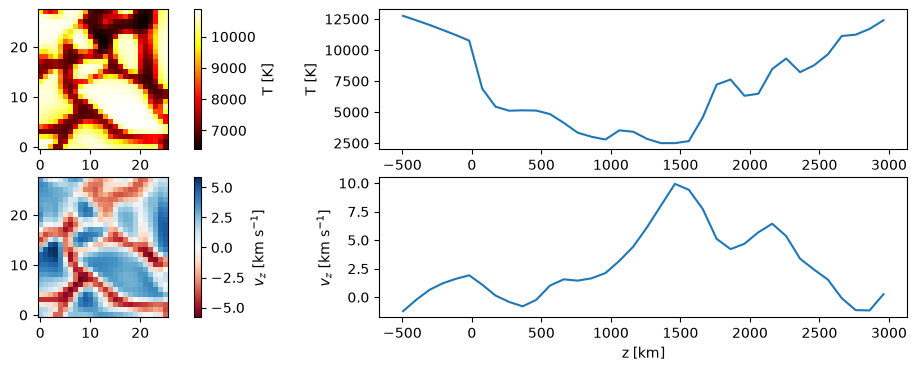

In [14]:
# We can fetch data for a figure
column = data.get_column(0,0,var=['h','T','vz'])
plane = data.get_plane(np.argmin(np.absolute(column['h'])),var=['T','vz'])

fig = plt.figure(figsize=(15,4))
ax = plt.subplot(221)
ref = ax.imshow(plane['T'],origin='lower',cmap='hot')
cb = fig.colorbar(ref,ax=ax)
cb.set_label('T [K]')
ax = plt.subplot(222)
ax.plot(column['h'],column['T'])
ax.set_xlabel('z [km]')
ax.set_ylabel('T [K]')
ax = plt.subplot(223)
ref = ax.imshow(plane['vz'],origin='lower',vmin=-np.max(np.absolute(plane['vz'])),vmax=np.max(np.absolute(plane['vz'])),cmap='RdBu')
cb = fig.colorbar(ref,ax=ax)
cb.set_label(r'$v_{z}$ [km s$^{-1}$]')
ax = plt.subplot(224)
ax.plot(column['h'],column['vz'])
ax.set_xlabel('z [km]')
ax.set_ylabel(r'$v_{z}$ [km s$^{-1}$]')
plt.show()

# 4. Wavelength file

Important: You must run the first example in order to run this one!

In this example we will select what wavelengths to take into consideration in an inversion by creating a weight file.

In [15]:
import hanlertmodlib as hrtml
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import hanlertio

In [16]:
# We load with hanlertio the file we created in example 1
data = hanlertio.hanlertio_class('example_data/inversion_example.tic',silent=True)

# We get the wavelength axis and the average intensity profile
wave = data.get_lambda()
intensity = np.mean(data.get_cube()['stokes'][:,:,0,:],axis=(0,1))

We take the average intensity profile to showcase the selected wavelengths.

Because of the limitations in the notebook environment, I will just showcase taking one every three wavelengths, but the selection must usually be physically motivated, this one is actually a terrible one.

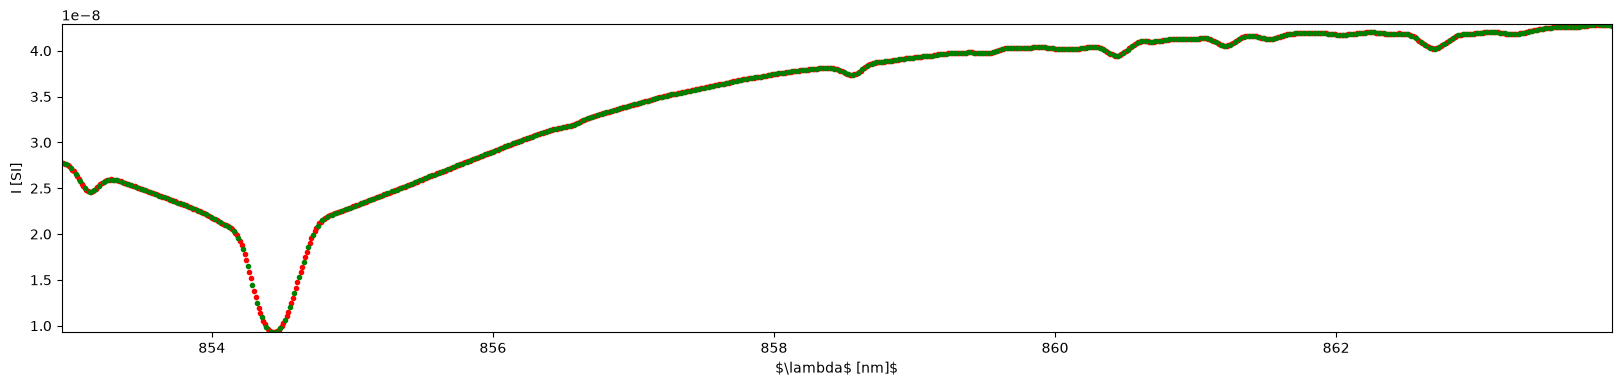

In [17]:
# Limits of the arrays
x0 = np.min(wave)
x1 = np.max(wave)
y0I = np.min(intensity)
y1I = np.max(intensity)
MIN = np.min([np.min(y0I)])
if MIN < 0:
    MIN = MIN*10.
else:
    MIN = -1.

# Select one every three
selected = range(0,wave.size,3)

# Create mask
mask = np.zeros(wave.shape)
mask[selected] = 1e0

# We plot the selected and rejected
fig = plt.figure(figsize=(20,4))
ax = plt.subplot()
ax.plot(wave,intensity*(1e0 - mask),'r',linestyle='none',marker='.')
ax.plot(wave,intensity*mask,'g',linestyle='none',marker='.')
ax.set_xlabel(r'$\lambda$ [nm]$')
ax.set_ylabel('I [SI]')
ax.axis((x0,x1,y0I,y1I))

plt.show()

And now we can generate the weight file. In the file we will assume the same selection for the four Stokes parameters

In [18]:
# Initialize the instance of the helper with the output file name
helper = hrtml.weight_class('example_data/inversion_example.weight')

# We set the default to 0. If we do not specify weights for a given Stokes parameter, it will assumme this number. The default of the class is 1.0
helper.set_default(0e0)

# We load the intensity weights
check = helper.load_data(mask,'I')
if check:
    print('Intensity weights loaded in the helper')
else:
    print('Could not load intensity weights')

# And we create the file
check = helper.create_file()
if check:
    print('Your weights file is ready at {0}'.format('example_data/inversion_example.weight'))
else:
    print('Could not create the file')
print('------------------------------------------')

Intensity weights loaded in the helper
Your weights file is ready at example_data/inversion_example.weight
------------------------------------------


And we can check that they are right by manually reading them

 - Weights for Stokes parameter 0 are between 0.0 and 1.0
      They add to 334.0
 - Weights for Stokes parameter 1 are between 0.0 and 0.0
 - Weights for Stokes parameter 2 are between 0.0 and 0.0
 - Weights for Stokes parameter 3 are between 0.0 and 0.0


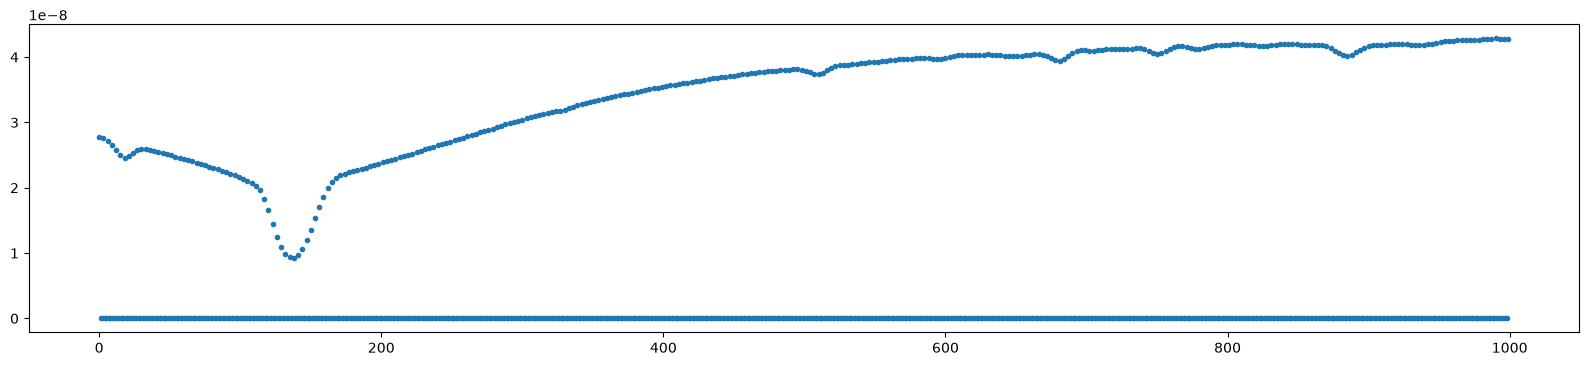

In [19]:
import struct
f = open('example_data/inversion_example.weight','rb')
nl,ns = struct.unpack('ii',f.read(8))
f.close()
weights = np.memmap('example_data/inversion_example.weight',mode='r',dtype=np.float64,offset=8,shape=(ns,nl))
for i in range(ns):
    print(f' - Weights for Stokes parameter {i} are between {np.min(weights[i,:])} and {np.max(weights[i,:])}')
    if np.max(weights[i,:]) > 0.:
        print(f'      They add to {np.sum(weights[i,:])}')

fig = plt.figure(figsize=(20,4))
plt.plot(intensity*weights[0,:],marker='.',linestyle='none')
plt.show()